# Product selection & demand dataset

1. selects ~10 representative products from the M5 catalog,
2. documents why each one was chosen,
3. aggregates their daily sales (summed across all 10 stores) into the clean `demand` table
   described in the project spec, and saves it to `data/processed/demand/`.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [13]:
calendar = pd.read_csv("../data/raw/m5/calendar.csv")
sales = pd.read_csv("../data/raw/m5/sales_train_validation.csv")

calendar["date"] = pd.to_datetime(calendar["date"])

DAY_COLUMNS = [col for col in sales.columns if col.startswith("d_")]

## Recompute the item-level summary

In [14]:
item_daily = sales.groupby("item_id")[DAY_COLUMNS].sum()
item_total_demand = item_daily.sum(axis=1)
item_avg_daily = item_total_demand / len(DAY_COLUMNS)
item_zero_ratio = (
    sales.set_index("item_id")[DAY_COLUMNS]
    .eq(0)
    .mean(axis=1)
    .groupby(level=0)
    .mean()
)
item_meta = sales.groupby("item_id")[["dept_id", "cat_id"]].first()

item_summary = (
    item_meta
    .join(item_total_demand.rename("total_demand"))
    .join(item_avg_daily.rename("avg_daily"))
    .join(item_zero_ratio.rename("zero_ratio"))
)

low_cut, high_cut = item_summary["total_demand"].quantile([0.33, 0.66])
item_summary["volume_tier"] = np.select(
    [item_summary["total_demand"] >= high_cut, item_summary["total_demand"] >= low_cut],
    ["high", "medium"],
    default="low",
)

item_summary.groupby(["cat_id", "volume_tier"]).size().unstack(fill_value=0)

volume_tier,high,low,medium
cat_id,,,
FOODS,698,257,482
HOBBIES,88,310,167
HOUSEHOLD,251,439,357


## Product selection

**Selection criteria:**

- Cover all three M5 categories (FOODS, HOUSEHOLD, HOBBIES), but **weighted toward FOODS**
  (4 of 10 products) since FOODS is both the largest category by item count (1437 items) and
  the highest-volume one in the real data. Treating all categories as equally sized would not
  reflect the actual product mix a manufacturer sourcing from this demand pattern would see.
- Within each category, pick a **mix of volume tiers** (high / medium / low), so the resulting
  factory has both fast-moving, capacity-constrained products and slow-moving, low-priority
  ones, this is what makes machine-allocation and setup-time tradeoffs interesting for the
  optimizer later.
- Spread picks across **different departments** within FOODS (FOODS_1/2/3) and HOUSEHOLD
  (HOUSEHOLD_1/2) rather than clustering in one, for variety in the assumed manufacturing
  process per product.
- Avoid over-indexing on the single top-selling item (~481 units/day, more than 3x the next
  highest), it is included once as a deliberate "flagship" high-volume / bottleneck product,
  balanced by a second, less extreme high-volume FOODS item so it doesn't dominate the whole
  scenario.

**Final selection** (`avg_daily` and `zero_ratio` computed from the M5 training data):

| product_id | m5_item_id | category | dept | tier | avg daily demand | zero-ratio | why chosen |
|---|---|---|---|---|---|---|---|
| P01 | FOODS_3_586 | FOODS | FOODS_3 | high | 481.0 | 0.005 | Highest-volume item in the whole dataset, near-continuous sales. Flagship high-volume / bottleneck product. |
| P02 | FOODS_1_218 | FOODS | FOODS_1 | high | 122.6 | 0.082 | Second high-volume FOODS product from a different department — diversifies FOODS without a second extreme outlier. |
| P03 | FOODS_3_395 | FOODS | FOODS_3 | medium | 8.0 | 0.530 | Representative medium-volume FOODS product. |
| P04 | FOODS_2_076 | FOODS | FOODS_2 | low | 2.9 | 0.782 | Low-volume specialty FOODS product from a third department. |
| P05 | HOUSEHOLD_1_083 | HOUSEHOLD | HOUSEHOLD_1 | high | 67.0 | 0.134 | High-volume HOUSEHOLD product. |
| P06 | HOUSEHOLD_1_176 | HOUSEHOLD | HOUSEHOLD_1 | medium | 8.0 | 0.522 | Medium-volume HOUSEHOLD product. |
| P07 | HOUSEHOLD_2_001 | HOUSEHOLD | HOUSEHOLD_2 | low | 2.9 | 0.768 | Low-volume HOUSEHOLD product from a different department. |
| P08 | HOBBIES_1_371 | HOBBIES | HOBBIES_1 | high | 64.1 | 0.280 | Highest-volume HOBBIES product. |
| P09 | HOBBIES_1_151 | HOBBIES | HOBBIES_1 | medium | 6.7 | 0.557 | Medium-volume HOBBIES product. |
| P10 | HOBBIES_1_225 | HOBBIES | HOBBIES_1 | low | 2.7 | 0.778 | Low-volume HOBBIES product. |

Category split: **4 FOODS / 3 HOUSEHOLD / 3 HOBBIES** (mirrors the real dataset's category
weight), each with a high/medium/low volume mix.

In [15]:
SELECTED_PRODUCTS = {
    "P01": "FOODS_3_586",
    "P02": "FOODS_1_218",
    "P03": "FOODS_3_395",
    "P04": "FOODS_2_076",
    "P05": "HOUSEHOLD_1_083",
    "P06": "HOUSEHOLD_1_176",
    "P07": "HOUSEHOLD_2_001",
    "P08": "HOBBIES_1_371",
    "P09": "HOBBIES_1_151",
    "P10": "HOBBIES_1_225",
}

In [16]:
item_to_product = {v: k for k, v in SELECTED_PRODUCTS.items()}

selection_check = item_summary.loc[list(SELECTED_PRODUCTS.values())].copy()
selection_check["product_id"] = selection_check.index.map(item_to_product)

selection_check[
    ["product_id", "cat_id", "dept_id", "volume_tier", "avg_daily", "zero_ratio"]
].sort_values("product_id")

,product_id,cat_id,dept_id,volume_tier,avg_daily,zero_ratio
item_id,,,,,,
FOODS_3_586,P01,FOODS,FOODS_3,high,481.046524,0.004600
FOODS_1_218,P02,FOODS,FOODS_1,high,122.631469,0.081861
FOODS_3_395,P03,FOODS,FOODS_3,medium,8.043387,0.530476
FOODS_2_076,P04,FOODS,FOODS_2,low,2.925248,0.781704
HOUSEHOLD_1_083,P05,HOUSEHOLD,HOUSEHOLD_1,high,66.961317,0.134239
HOUSEHOLD_1_176,P06,HOUSEHOLD,HOUSEHOLD_1,medium,8.006273,0.521798
HOUSEHOLD_2_001,P07,HOUSEHOLD,HOUSEHOLD_2,low,2.929953,0.768374
HOBBIES_1_371,P08,HOBBIES,HOBBIES_1,high,64.069524,0.279718
HOBBIES_1_151,P09,HOBBIES,HOBBIES_1,medium,6.669629,0.557135


## Build the demand table

For each selected product, sum daily sales **across all 10 stores** to get a single national
demand series per product, this is the demand a manufacturing company supplying the whole
market would see, and it avoids the extreme store-level intermittency observed in notebook 01.

Daily granularity is kept (needed for forecasting); a sequential `week` index is added from the
calendar's `wm_yr_wk` for later weekly production planning.

In [17]:
week_lookup = calendar[["d", "date", "wm_yr_wk"]].drop_duplicates().sort_values("date")

unique_weeks = week_lookup["wm_yr_wk"].drop_duplicates().tolist()
week_number = {wk: i + 1 for i, wk in enumerate(unique_weeks)}
week_lookup["week"] = week_lookup["wm_yr_wk"].map(week_number)

week_lookup[["d", "date", "week"]].head()

,d,date,week
0,d_1,2011-01-29,1
1,d_2,2011-01-30,1
2,d_3,2011-01-31,1
3,d_4,2011-02-01,1
4,d_5,2011-02-02,1


In [18]:
selected_daily = (
    sales[sales["item_id"].isin(SELECTED_PRODUCTS.values())]
    .groupby("item_id")[DAY_COLUMNS]
    .sum()
)

demand = (
    selected_daily
    .reset_index()
    .melt(id_vars="item_id", var_name="d", value_name="demand")
    .merge(week_lookup[["d", "date", "week"]], on="d", how="left")
    .merge(item_meta[["cat_id"]], left_on="item_id", right_index=True, how="left")
)

demand["product_id"] = demand["item_id"].map(item_to_product)
demand = demand.rename(columns={"item_id": "m5_item_id", "cat_id": "category"})
demand = demand[["product_id", "m5_item_id", "date", "demand", "week", "category"]]
demand = demand.sort_values(["product_id", "date"]).reset_index(drop=True)

# Drop any partial week. `sales_train_validation` only has 1913 daily columns (up to
# 2016-04-24), not the full 1969-day calendar (which extends to 2016-06-19) — so day
# counts must be computed from `demand` itself, not from the full `week_lookup`, or the
# actual partial week (the last one actually present in the data) won't be detected.
days_per_week = demand.groupby("week")["date"].nunique()
partial_weeks = days_per_week[days_per_week != 7].index.tolist()
print("Dropping incomplete week(s) from demand:", partial_weeks)

demand = demand[~demand["week"].isin(partial_weeks)].reset_index(drop=True)

demand.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_30364\2000949836.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


Dropping incomplete week(s) from demand: [274]


,product_id,m5_item_id,date,demand,week,category
0,P01,FOODS_3_586,2011-01-29,516,1,FOODS
1,P01,FOODS_3_586,2011-01-30,479,1,FOODS
2,P01,FOODS_3_586,2011-01-31,328,1,FOODS
3,P01,FOODS_3_586,2011-02-01,376,1,FOODS
4,P01,FOODS_3_586,2011-02-02,319,1,FOODS


In [19]:
print("Rows:", len(demand))
print("Products:", demand["product_id"].nunique())
print("Date range:", demand["date"].min().date(), "to", demand["date"].max().date())
print("\nMissing values:")
print(demand.isna().sum())
print("\nNegative demand rows:", (demand["demand"] < 0).sum())

demand.groupby("product_id")["demand"].agg(["sum", "mean", "max"])

Rows: 19110
Products: 10
Date range: 2011-01-29 to 2016-04-22

Missing values:
product_id    0
m5_item_id    0
date          0
demand        0
week          0
category      0
dtype: int64

Negative demand rows: 0


,sum,mean,max
product_id,,,
P01,919316,481.065411,1147
P02,234355,122.634746,400
P03,15367,8.041340,25
P04,5584,2.922030,20
P05,127975,66.967556,181
P06,15301,8.006803,26
P07,5602,2.931450,12
P08,122473,64.088435,234
P09,12741,6.667190,24


## Save the clean demand dataset

In [20]:
output_dir = Path("../data/processed/demand")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "demand.csv"
demand.to_csv(output_path, index=False)

print("Saved:", output_path.resolve())
print("Shape:", demand.shape)

Saved: C:\Users\HP\Walid\Industrial_production_optimization\data\processed\demand\demand.csv
Shape: (19110, 6)


## Visual check

Weekly-aggregated demand for each of the 10 selected products, as a sanity check that the
high/medium/low volume mix and category spread look as intended.

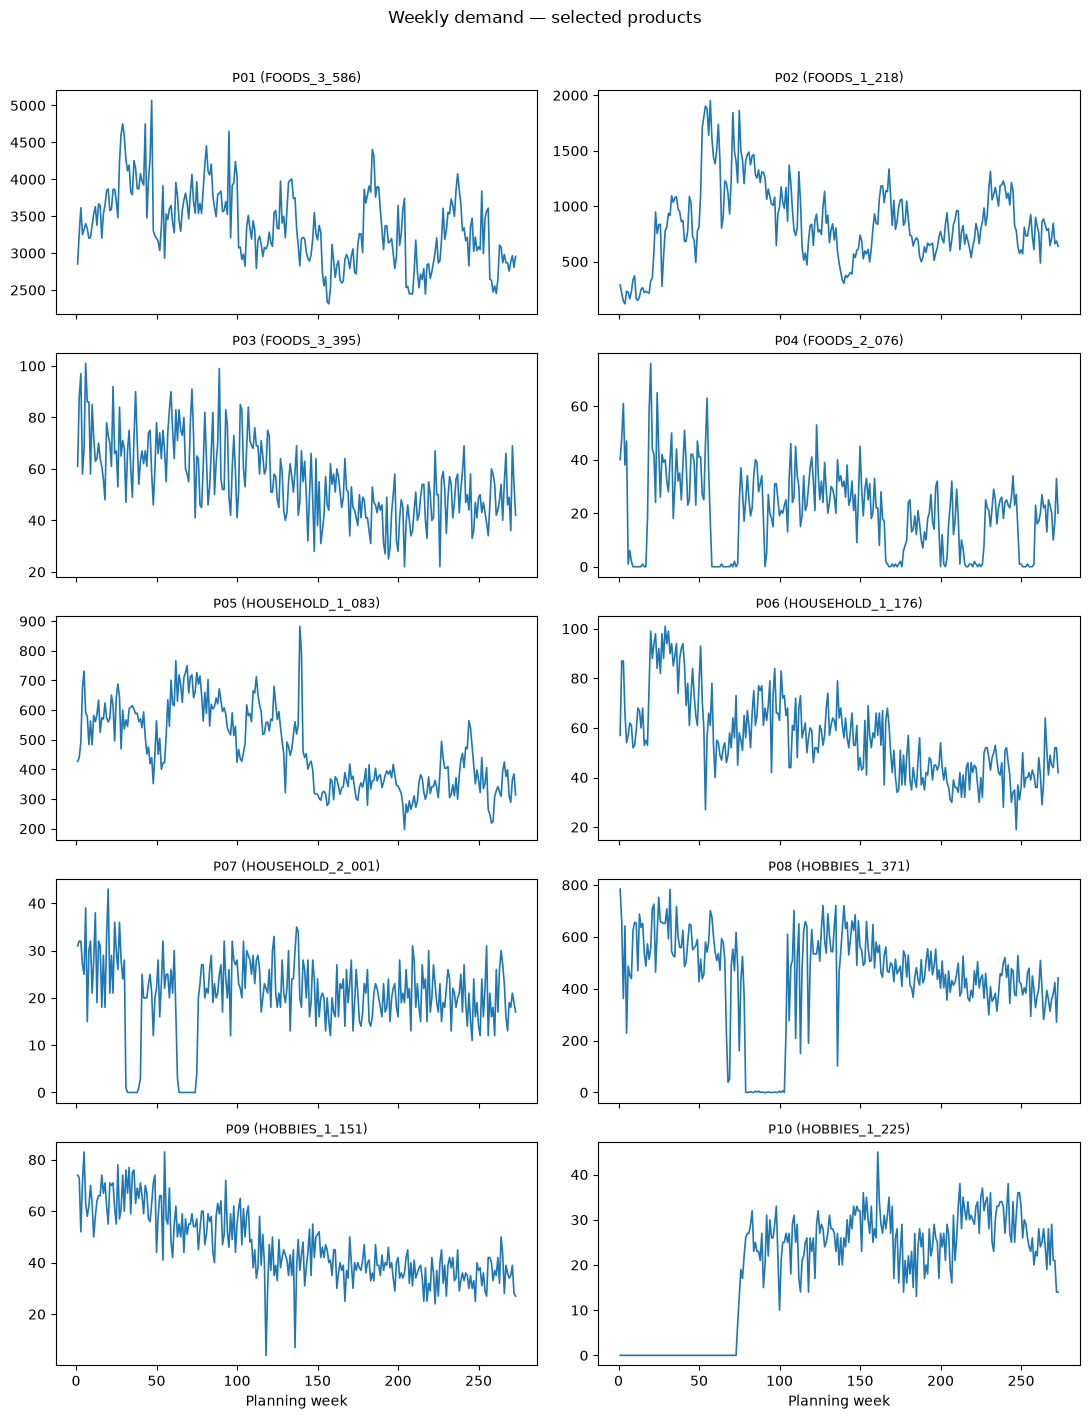

In [21]:
weekly = demand.groupby(["product_id", "week"])["demand"].sum().reset_index()
product_order = list(SELECTED_PRODUCTS.keys())

fig, axes = plt.subplots(5, 2, figsize=(11, 14), sharex=True)

for ax, product_id in zip(axes.flat, product_order):
    series = weekly[weekly["product_id"] == product_id]
    ax.plot(series["week"], series["demand"], linewidth=1.2)
    ax.set_title(f"{product_id} ({SELECTED_PRODUCTS[product_id]})", fontsize=9)

for ax in axes[-1]:
    ax.set_xlabel("Planning week")

fig.suptitle("Weekly demand \u2014 selected products", y=1.01)
fig.tight_layout()
plt.show()